### Markov decision process

This week's methods are all built to solve __M__arkov __D__ecision __P__rocesses. In the broadest sense, an MDP is defined by how it changes states and how rewards are computed.

State transition is defined by $P(s' |s,a)$ - how likely are you to end at state $s'$ if you take action $a$ from state $s$. Now there's more than one way to define rewards, but we'll use $r(s,a,s')$ function for convenience.

_This notebook is inspired by the awesome_ [CS294](https://github.com/berkeleydeeprlcourse/homework/blob/36a0b58261acde756abd55306fbe63df226bf62b/hw2/HW2.ipynb) _by Berkeley_

For starters, let's define a simple MDP from this picture:

<img src="https://upload.wikimedia.org/wikipedia/commons/a/ad/Markov_Decision_Process.svg" width="400px" alt="Diagram by Waldoalvarez via Wikimedia Commons, CC BY-SA 4.0"/>

In [692]:
import sys, os
if 'google.colab' in sys.modules and not os.path.exists('.setup_complete'):
    !wget -q https://raw.githubusercontent.com/yandexdataschool/Practical_RL/master/setup_colab.sh -O- | bash
    !wget -q https://raw.githubusercontent.com/yandexdataschool/Practical_RL/master/week02_value_based/mdp.py
    !touch .setup_complete

# This code creates a virtual display to draw game images on.
# It will have no effect if your machine has a monitor.
if type(os.environ.get("DISPLAY")) is not str or len(os.environ.get("DISPLAY")) == 0:
    !bash ../xvfb start
    os.environ['DISPLAY'] = ':1'

In [693]:
import numpy as np

In [694]:
transition_probs = {
    's0': {
        'a0': {'s0': 0.5, 's2': 0.5},
        'a1': {'s2': 1}
    },
    's1': {
        'a0': {'s0': 0.7, 's1': 0.1, 's2': 0.2},
        'a1': {'s1': 0.95, 's2': 0.05}
    },
    's2': {
        'a0': {'s0': 0.4, 's2': 0.6},
        'a1': {'s0': 0.3, 's1': 0.3, 's2': 0.4}
    }
}
rewards = {
    's1': {'a0': {'s0': +5}},
    's2': {'a1': {'s0': -1}}
}

from mdp import MDP
mdp = MDP(transition_probs, rewards, initial_state='s0')

We can now use MDP just as any other gym environment:

In [695]:
print('initial state =', mdp.reset())
next_state, reward, done, info = mdp.step('a1')
print('next_state = %s, reward = %s, done = %s' % (next_state, reward, done))

initial state = s0
next_state = s2, reward = 0.0, done = False


but it also has other methods that you'll need for Value Iteration

In [696]:
print("mdp.get_all_states =", mdp.get_all_states())
print("mdp.get_possible_actions('s1') = ", mdp.get_possible_actions('s1'))
print("mdp.get_next_states('s1', 'a0') = ", mdp.get_next_states('s1', 'a0'))
print("mdp.get_reward('s1', 'a0', 's0') = ", mdp.get_reward('s1', 'a0', 's0'))
print("mdp.get_transition_prob('s1', 'a0', 's0') = ", mdp.get_transition_prob('s1', 'a0', 's0'))

mdp.get_all_states = ('s0', 's1', 's2')
mdp.get_possible_actions('s1') =  ('a0', 'a1')
mdp.get_next_states('s1', 'a0') =  {'s0': 0.7, 's1': 0.1, 's2': 0.2}
mdp.get_reward('s1', 'a0', 's0') =  5
mdp.get_transition_prob('s1', 'a0', 's0') =  0.7


### Optional: Visualizing MDPs

You can also visualize any MDP with the drawing fuction donated by [neer201](https://github.com/neer201).

You have to install graphviz for system and for python. 

1. * For ubuntu just run: `sudo apt-get install graphviz` 
   * For OSX: `brew install graphviz`
2. `pip install graphviz`
3. restart the notebook

__Note:__ Installing graphviz on some OS (esp. Windows) may be tricky. However, you can ignore this part alltogether and use the standart vizualization.

In [697]:
from mdp import has_graphviz
from IPython.display import display
print("Graphviz available:", has_graphviz)

Graphviz available: True


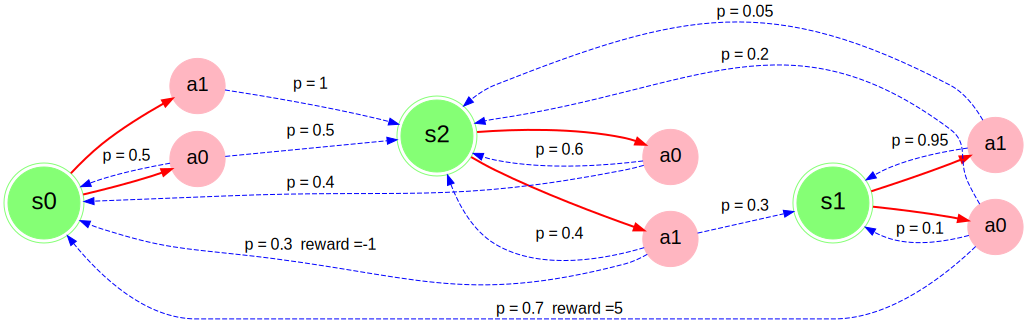

In [698]:
if has_graphviz:
    from mdp import plot_graph, plot_graph_with_state_values, plot_graph_optimal_strategy_and_state_values
    display(plot_graph(mdp))

### Value Iteration

Now let's build something to solve this MDP. The simplest algorithm so far is __V__alue __I__teration

Here's the pseudo-code for VI:

---

`1.` Initialize $V^{(0)}(s)=0$, for all $s$

`2.` For $i=0, 1, 2, \dots$
 
`3.` $ \quad V_{(i+1)}(s) = \max_a \sum_{s'} P(s' | s,a) \cdot [ r(s,a,s') + \gamma V_{i}(s')]$, for all $s$

---

First, let's write a function to compute the state-action value function $Q^{\pi}$, defined as follows

$$Q_i(s, a) = \sum_{s'} P(s' | s,a) \cdot [ r(s,a,s') + \gamma V_{i}(s')]$$


In [699]:
def get_action_value(mdp: MDP, state_values, state, action, gamma):
    """ Computes Q(s,a) as in formula above """
    return sum([mdp.get_transition_prob(state, action, s0) * (mdp.get_reward(state, action, s0) + gamma * state_values[s0])
                     for s0 in mdp.get_next_states(state, action)])

In [700]:
test_Vs = {s: i for i, s in enumerate(sorted(mdp.get_all_states()))}
assert np.isclose(get_action_value(mdp, test_Vs, 's2', 'a1', 0.9), 0.69)
assert np.isclose(get_action_value(mdp, test_Vs, 's1', 'a0', 0.9), 3.95)

Using $Q(s,a)$ we can now define the "next" V(s) for value iteration.
 $$V_{(i+1)}(s) = \max_a \sum_{s'} P(s' | s,a) \cdot [ r(s,a,s') + \gamma V_{i}(s')] = \max_a Q_i(s,a)$$

In [701]:
def get_new_state_value(mdp: MDP, state_values, state, gamma):
    """ Computes next V(s) as in formula above. Please do not change state_values in process. """
    if mdp.is_terminal(state):
        return 0
    
    return max(get_action_value(mdp, state_values, state, action, gamma) for action in mdp.get_possible_actions(state))

In [702]:
test_Vs_copy = dict(test_Vs)
assert np.isclose(get_new_state_value(mdp, test_Vs, 's0', 0.9), 1.8)
assert np.isclose(get_new_state_value(mdp, test_Vs, 's2', 0.9), 1.08)
assert np.isclose(get_new_state_value(mdp, {'s0': -1e10, 's1': 0, 's2': -2e10}, 's0', 0.9), -13500000000.0), \
    "Please ensure that you handle negative Q-values of arbitrary magnitude correctly"
assert test_Vs == test_Vs_copy, "Please do not change state_values in get_new_state_value"

Finally, let's combine everything we wrote into a working value iteration algo.

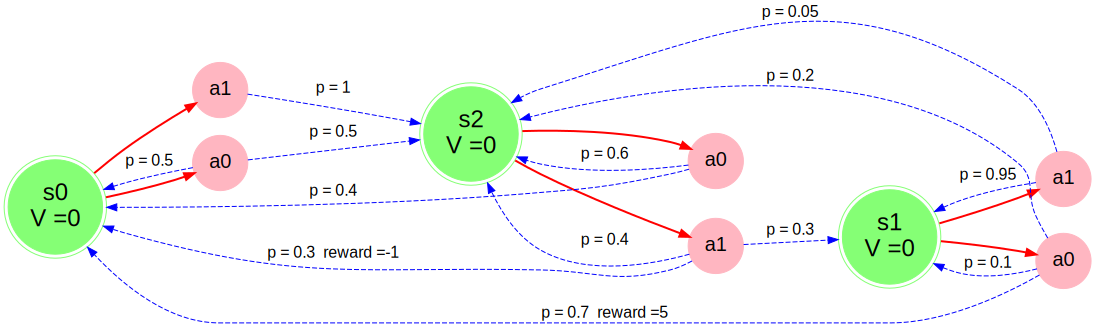

iter    0   |   diff: 3.50000   |   V(s0) = 0.000   V(s1) = 0.000   V(s2) = 0.000
iter    1   |   diff: 0.64500   |   V(s0) = 0.000   V(s1) = 3.500   V(s2) = 0.000
iter    2   |   diff: 0.58050   |   V(s0) = 0.000   V(s1) = 3.815   V(s2) = 0.645
iter    3   |   diff: 0.43582   |   V(s0) = 0.581   V(s1) = 3.959   V(s2) = 0.962
iter    4   |   diff: 0.30634   |   V(s0) = 0.866   V(s1) = 4.395   V(s2) = 1.272
iter    5   |   diff: 0.27571   |   V(s0) = 1.145   V(s1) = 4.670   V(s2) = 1.579
iter    6   |   diff: 0.24347   |   V(s0) = 1.421   V(s1) = 4.926   V(s2) = 1.838
iter    7   |   diff: 0.21419   |   V(s0) = 1.655   V(s1) = 5.169   V(s2) = 2.075
iter    8   |   diff: 0.19277   |   V(s0) = 1.868   V(s1) = 5.381   V(s2) = 2.290
iter    9   |   diff: 0.17327   |   V(s0) = 2.061   V(s1) = 5.573   V(s2) = 2.481
iter   10   |   diff: 0.15569   |   V(s0) = 2.233   V(s1) = 5.746   V(s2) = 2.654
iter   11   |   diff: 0.14012   |   V(s0) = 2.389   V(s1) = 5.902   V(s2) = 2.810
iter   12   |   

In [703]:
# parameters
gamma = 0.9            # discount for MDP
num_iter = 100         # maximum iterations, excluding initialization
# stop VI if new values are this close to old values (or closer)
min_difference = 0.001

# initialize V(s)
state_values = {s: 0 for s in mdp.get_all_states()}

if has_graphviz:
    display(plot_graph_with_state_values(mdp, state_values))

for i in range(num_iter):

    # Compute new state values using the functions you defined above.
    # It must be a dict {state : float V_new(state)}
    new_state_values = {state: get_new_state_value(mdp, state_values, state, gamma) for state in mdp.get_all_states()}

    assert isinstance(new_state_values, dict)

    # Compute difference
    diff = max(abs(new_state_values[s] - state_values[s])
               for s in mdp.get_all_states())
    print("iter %4i   |   diff: %6.5f   |   " % (i, diff), end="")
    print('   '.join("V(%s) = %.3f" % (s, v) for s, v in state_values.items()))
    state_values = new_state_values

    if diff < min_difference:
        print("Terminated")
        break

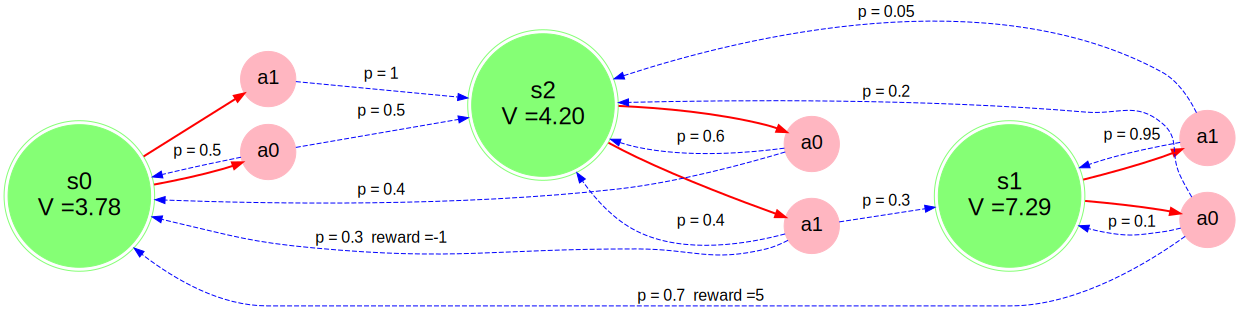

In [704]:
if has_graphviz:
    display(plot_graph_with_state_values(mdp, state_values))

In [705]:
print("Final state values:", state_values)

assert abs(state_values['s0'] - 3.781) < 0.01
assert abs(state_values['s1'] - 7.294) < 0.01
assert abs(state_values['s2'] - 4.202) < 0.01

Final state values: {'s0': 3.7810348735476405, 's1': 7.29400642386723, 's2': 4.202140275227049}


Now let's use those $V^{*}(s)$ to find optimal actions in each state

 $$\pi^*(s) = argmax_a \sum_{s'} P(s' | s,a) \cdot [ r(s,a,s') + \gamma V_{i}(s')] = argmax_a Q_i(s,a)$$
 
The only difference vs V(s) is that here we take not max but argmax: find action such with maximum Q(s,a).

In [706]:
def get_optimal_action(mdp: MDP, state_values: dict, state, gamma=0.9):
    """ Finds optimal action using formula above. """
    if mdp.is_terminal(state):
        return None

    actions = mdp.get_possible_actions(state)
    return actions[np.argmax([get_action_value(mdp, state_values, state, action, gamma) for action in actions])]

In [707]:
assert get_optimal_action(mdp, state_values, 's0', gamma) == 'a1'
assert get_optimal_action(mdp, state_values, 's1', gamma) == 'a0'
assert get_optimal_action(mdp, state_values, 's2', gamma) == 'a1'

assert get_optimal_action(mdp, {'s0': -1e10, 's1': 0, 's2': -2e10}, 's0', 0.9) == 'a0', \
    "Please ensure that you handle negative Q-values of arbitrary magnitude correctly"
assert get_optimal_action(mdp, {'s0': -2e10, 's1': 0, 's2': -1e10}, 's0', 0.9) == 'a1', \
    "Please ensure that you handle negative Q-values of arbitrary magnitude correctly"

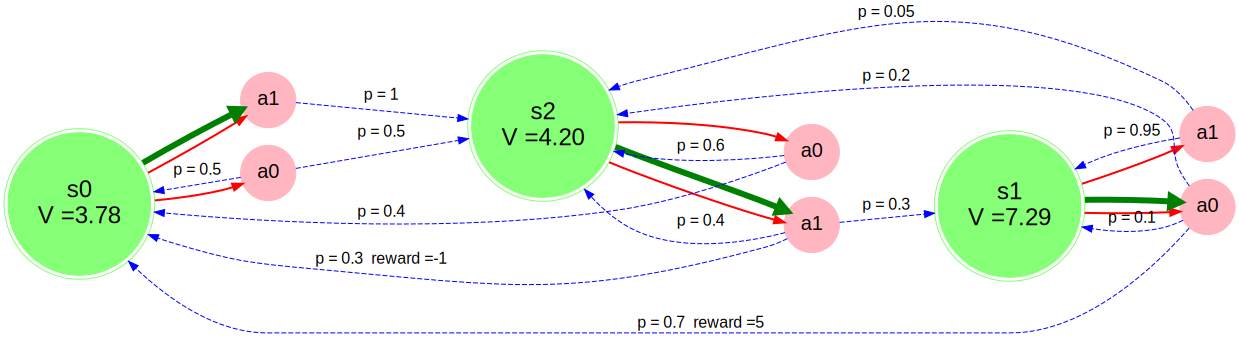

In [708]:
if has_graphviz:
    display(plot_graph_optimal_strategy_and_state_values(mdp, state_values, get_action_value))

In [709]:
# Measure agent's average reward

s = mdp.reset()
rewards = []
for _ in range(10000):
    s, r, done, _ = mdp.step(get_optimal_action(mdp, state_values, s, gamma))
    rewards.append(r)

print("average reward: ", np.mean(rewards))

assert(0.40 < np.mean(rewards) < 0.55)

average reward:  0.4524


### Frozen lake

In [710]:
from mdp import FrozenLakeEnv
mdp = FrozenLakeEnv(slip_chance=0)

mdp.render()

*FFF
FHFH
FFFH
HFFG



In [711]:
def value_iteration(mdp, state_values=None, gamma=0.9, num_iter=1000, min_difference=1e-5):
    """ performs num_iter value iteration steps starting from state_values. Same as before but in a function """
    state_values = state_values or {s: 0 for s in mdp.get_all_states()}
    last = 0
    for i in range(num_iter):
        last = i
        # Compute new state values using the functions you defined above. It must be a dict {state : new_V(state)}
        new_state_values = {state: get_new_state_value(mdp, state_values, state, gamma) for state in mdp.get_all_states()}

        assert isinstance(new_state_values, dict)

        # Compute difference between value function values
        diff = max(abs(new_state_values[s] - state_values[s])
                   for s in mdp.get_all_states())

        # print("iter %4i   |   diff: %6.5f   |   V(start): %.3f " %
        #       (i, diff, new_state_values[mdp._initial_state]))

        state_values = new_state_values
        if diff < min_difference:
            break

    print(f'Value iteration is done after {last+1} iterations')
    return state_values

In [712]:
state_values = value_iteration(mdp)

Value iteration is done after 7 iterations


In [713]:
s = mdp.reset()
mdp.render()
for t in range(100):
    a = get_optimal_action(mdp, state_values, s, gamma)
    print(a, end='\n\n')
    s, r, done, _ = mdp.step(a)
    mdp.render()
    if done:
        break

*FFF
FHFH
FFFH
HFFG

down

SFFF
*HFH
FFFH
HFFG

down

SFFF
FHFH
*FFH
HFFG

right

SFFF
FHFH
F*FH
HFFG

down

SFFF
FHFH
FFFH
H*FG

right

SFFF
FHFH
FFFH
HF*G

right

SFFF
FHFH
FFFH
HFF*



### Let's visualize!

It's usually interesting to see what your algorithm actually learned under the hood. To do so, we'll plot state value functions and optimal actions at each VI step.

In [714]:
import matplotlib.pyplot as plt
%matplotlib inline


def draw_policy(mdp, state_values):
    plt.figure(figsize=(3, 3))
    h, w = mdp.desc.shape
    states = sorted(mdp.get_all_states())
    V = np.array([state_values[s] for s in states])
    Pi = {s: get_optimal_action(mdp, state_values, s, gamma) for s in states}
    # the more the state value is, the brighter the color
    plt.imshow(V.reshape(w, h), cmap='gray', interpolation='none', clim=(0, 1))
    ax = plt.gca()
    ax.set_xticks(np.arange(h)-.5)
    ax.set_yticks(np.arange(w)-.5)
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    Y, X = np.mgrid[0:4, 0:4]
    a2uv = {'left': (-1, 0), 'down': (0, -1), 'right': (1, 0), 'up': (0, 1)}
    for y in range(h):
        for x in range(w):
            plt.text(x, y, str(mdp.desc[y, x].item()),
                     color='g', size=12,  verticalalignment='center',
                     horizontalalignment='center', fontweight='bold')
            a = Pi[y, x]
            if a is None:
                continue
            u, v = a2uv[a]
            plt.arrow(x, y, u*.3, -v*.3, color='m',
                      head_width=0.1, head_length=0.1)
    plt.grid(color='b', lw=2, ls='-')
    plt.show()

after iteration 0
Value iteration is done after 1 iterations


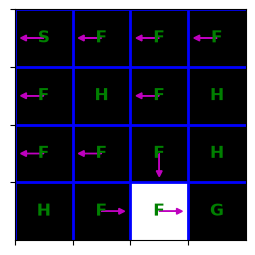

after iteration 1
Value iteration is done after 1 iterations


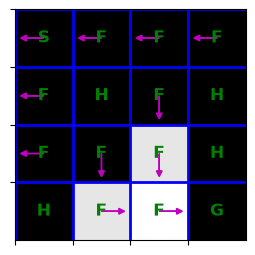

after iteration 2
Value iteration is done after 1 iterations


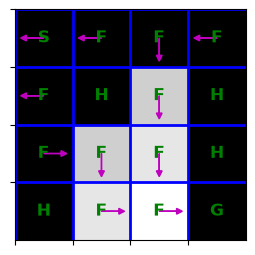

after iteration 3
Value iteration is done after 1 iterations


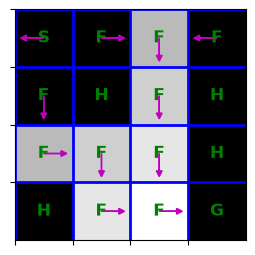

after iteration 4
Value iteration is done after 1 iterations


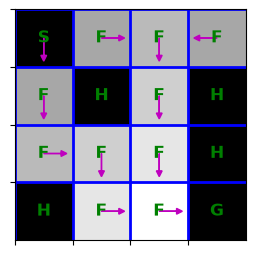

after iteration 5
Value iteration is done after 1 iterations


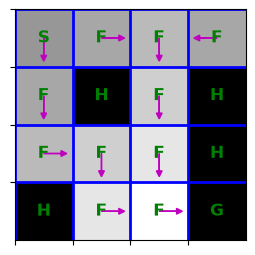

after iteration 6
Value iteration is done after 1 iterations


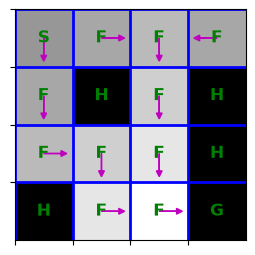

after iteration 7
Value iteration is done after 1 iterations


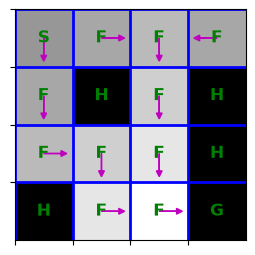

after iteration 8
Value iteration is done after 1 iterations


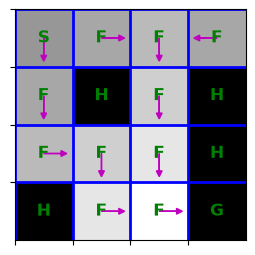

after iteration 9
Value iteration is done after 1 iterations


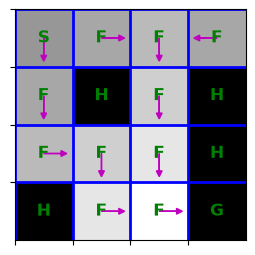

In [715]:
state_values = {s: 0 for s in mdp.get_all_states()}

for i in range(10):
    print(f"after iteration {i}")
    state_values = value_iteration(mdp, state_values, num_iter=1)
    draw_policy(mdp, state_values)
# please ignore iter 0 at each step

after iteration 19
Value iteration is done after 1 iterations


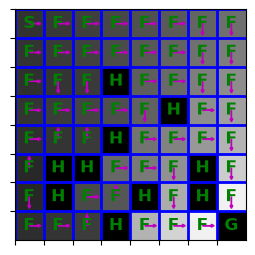

In [716]:
from IPython.display import clear_output
from time import sleep
mdp = FrozenLakeEnv(map_name='8x8', slip_chance=0.1)
state_values = {s: 0 for s in mdp.get_all_states()}

for i in range(20):
    clear_output(True)
    print(f"after iteration {i}")
    state_values = value_iteration(mdp, state_values, num_iter=1)
    draw_policy(mdp, state_values)
    sleep(0.5)
# please ignore iter 0 at each step

Massive tests

In [717]:
mdp = FrozenLakeEnv(slip_chance=0)
state_values = value_iteration(mdp)

total_rewards = []
for game_i in range(1000):
    s = mdp.reset()
    rewards = []
    for t in range(100):
        s, r, done, _ = mdp.step(
            get_optimal_action(mdp, state_values, s, gamma))
        rewards.append(r)
        if done:
            break
    total_rewards.append(np.sum(rewards))

print("average reward: ", np.mean(total_rewards))
assert(1.0 <= np.mean(total_rewards) <= 1.0)
print("Well done!")

Value iteration is done after 7 iterations
average reward:  1.0
Well done!


In [718]:
# Measure agent's average reward
mdp = FrozenLakeEnv(slip_chance=0.1)
state_values = value_iteration(mdp)

total_rewards = []
for game_i in range(1000):
    s = mdp.reset()
    rewards = []
    for t in range(100):
        s, r, done, _ = mdp.step(
            get_optimal_action(mdp, state_values, s, gamma))
        rewards.append(r)
        if done:
            break
    total_rewards.append(np.sum(rewards))

print("average reward: ", np.mean(total_rewards))
assert(0.8 <= np.mean(total_rewards) <= 0.95)
print("Well done!")

Value iteration is done after 17 iterations
average reward:  0.876
Well done!


In [719]:
# Measure agent's average reward
mdp = FrozenLakeEnv(slip_chance=0.25)
state_values = value_iteration(mdp)

total_rewards = []
for game_i in range(1000):
    s = mdp.reset()
    rewards = []
    for t in range(100):
        s, r, done, _ = mdp.step(
            get_optimal_action(mdp, state_values, s, gamma))
        rewards.append(r)
        if done:
            break
    total_rewards.append(np.sum(rewards))

print("average reward: ", np.mean(total_rewards))
assert(0.6 <= np.mean(total_rewards) <= 0.7)
print("Well done!")

Value iteration is done after 22 iterations
average reward:  0.659
Well done!


In [720]:
# Measure agent's average reward
mdp = FrozenLakeEnv(slip_chance=0.2, map_name='8x8')
state_values = value_iteration(mdp)

total_rewards = []
for game_i in range(1000):
    s = mdp.reset()
    rewards = []
    for t in range(100):
        s, r, done, _ = mdp.step(
            get_optimal_action(mdp, state_values, s, gamma))
        rewards.append(r)
        if done:
            break
    total_rewards.append(np.sum(rewards))

print("average reward: ", np.mean(total_rewards))
assert(0.6 <= np.mean(total_rewards) <= 0.8)
print("Well done!")

Value iteration is done after 34 iterations
average reward:  0.743
Well done!


# HW Part 1: Value iteration convergence

### Find an MDP for which value iteration takes long to converge  (1 pts)

When we ran value iteration on the small frozen lake problem, the last iteration where an action changed was iteration 6--i.e., value iteration computed the optimal policy at iteration 6. Are there any guarantees regarding how many iterations it'll take value iteration to compute the optimal policy? There are no such guarantees without additional assumptions--we can construct the MDP in such a way that the greedy policy will change after arbitrarily many iterations.

Your task: define an MDP with at most 3 states and 2 actions, such that when you run value iteration, the optimal action changes at iteration >= 50. Use discount=0.95. (However, note that the discount doesn't matter here--you can construct an appropriate MDP with any discount.)

Note: value function must change at least once after iteration >=50, not necessarily change on every iteration till >=50.

In [721]:
# state, action, final state, final state prob
# from state with action can move to ... with prob
# at most 3 states, 2 actions

# to make policy change with 2 actions we should force it to choose between them at each iteration
# it's dumb to have 1 possible action from state
# i think it's time to draw :(

# state, action, final state, reward, I don't know why not to keep it as tuple (as we can hash it too)
# inner state is the next one

# interesting, is it intellectual task)
from numpy import random
from mdp import MDP
transition_probs = {
    's0': {
        'a0': {'s1': 1},
        'a1': {'s2': 1}
    },
    's1': {
        'a0': {'s0': 1},
        'a1': {'s2': 1}
    },
    's2': {
        'a0': {'s0': 1},
        'a1': {'s1': 1}
    }
}
# rewards = {
#     's0': {
#         'a0': {'s1': -1.001},
#         'a1': {'s2': -1.001}
#     },
#     's1': {
#         'a0': {'s0': 1.999},
#         'a1': {'s2': 0.001}
#     },
#     's2': {
#         'a0': {'s0': 0.001},
#         'a1': {'s1': 1.999}
#     },
# }

gamma = 0.95
x = 10

rewards = {
    's0': {
        'a0': {'s1': -x},
        'a1': {'s2': -x}
    },
    's1': {
        'a0': {'s0': x},
        'a1': {'s2': 0}
    },
    's2': {
        'a0': {'s0': x},
        'a1': {'s1': 0}
    },
}

# Feel free to change the initial_state
# mdp = MDP(transition_probs, rewards, initial_state=random.choice(tuple(transition_probs.keys())))
mdp = MDP(transition_probs, rewards, initial_state='s0')


state_values = {s: 0 for s in mdp.get_all_states()}
policy = np.array([get_optimal_action(mdp, state_values, state, gamma)
                   for state in sorted(mdp.get_all_states())])

# value iteration is 1 iteration for evaluating value of policy, and then stage of policy improvement
# in policy iteration there are many iteration for finding the value of policy
for i in range(52):
    print(f"after iteration {i}")
    state_values = value_iteration(mdp, state_values, num_iter=1)
    # print(state_values)

    new_policy = np.array([get_optimal_action(mdp, state_values, state, gamma)
                           for state in sorted(mdp.get_all_states())])

    # should last at least for 50 iteration
    n_changes = (policy != new_policy).sum()
    print(f"N actions changed = {n_changes}")
    if n_changes != 0:
        print('#' * 40)
        print(f"Last change at {i}")
        print('#' * 40)

    policy = new_policy

# please ignore iter 0 at each step

after iteration 0
Value iteration is done after 1 iterations
N actions changed = 2
########################################
Last change at 0
########################################
after iteration 1
Value iteration is done after 1 iterations
N actions changed = 2
########################################
Last change at 1
########################################
after iteration 2
Value iteration is done after 1 iterations
N actions changed = 2
########################################
Last change at 2
########################################
after iteration 3
Value iteration is done after 1 iterations
N actions changed = 2
########################################
Last change at 3
########################################
after iteration 4
Value iteration is done after 1 iterations
N actions changed = 2
########################################
Last change at 4
########################################
after iteration 5
Value iteration is done after 1 iterations
N actions changed = 2
#######


### 1. Value Iteration (VI)
*   **Value Update:** You update the value function **many times** (iteratively).
*   **Policy Extraction:** You extract the policy only **once**, at the very end (or implicitly via $\arg\max$ during updates).
*   **Mechanism:** Each iteration applies the Bellman Optimality Operator: $V_{k+1} = \mathcal{T}V_k$. You are directly approximating $V^*$ without ever committing to a specific policy during the process. The policy is merely a byproduct of the current value estimate.
*   **Analogy:** You are constantly refining your *estimate* of the best possible outcome, and only when you're satisfied do you decide what actions to take.

### 2. Policy Iteration (PI)
*   **Value Update:** You solve for the value function **exactly** (in one step, typically via linear algebra or iterative evaluation until convergence) for a *fixed* policy.
*   **Policy Improvement:** You then improve the policy based on that exact value function, and repeat.
*   **Mechanism:** It alternates between two distinct phases:
    1.  **Policy Evaluation:** Compute $V^\pi$ exactly for the current $\pi$.
    2.  **Policy Improvement:** Update $\pi'(s) = \arg\max_a [r(s,a) + \gamma \mathbb{E}[V^\pi(s')]]$.
*   **Analogy:** You pick a strategy, fully analyze how good it is, tweak it to be better, and then re-analyze the new strategy from scratch.

### Value iteration convervence proof (1 pts)
**Note:** Assume that $\mathcal{S}, \mathcal{A}$ are finite.

Update of value function in value iteration can be rewritten in a form of Bellman operator:

$$(TV)(s) = \max_{a \in \mathcal{A}}\mathbb{E}\left[ r_{t+1} + \gamma V(s_{t+1}) | s_t = s, a_t = a\right]$$

Value iteration algorithm with Bellman operator:

---
&nbsp;&nbsp; Initialize $V_0$

&nbsp;&nbsp; **for** $k = 0,1,2,...$ **do**

&nbsp;&nbsp;&nbsp;&nbsp; $V_{k+1} \leftarrow TV_k$

&nbsp;&nbsp;**end for**

---

In [lecture](https://docs.google.com/presentation/d/1lz2oIUTvd2MHWKEQSH8hquS66oe4MZ_eRvVViZs2uuE/edit#slide=id.g4fd6bae29e_2_4) we established contraction property of bellman operator:

$$
||TV - TU||_{\infty} \le \gamma ||V - U||_{\infty}
$$

For all $V, U$

Using contraction property of Bellman operator, Banach fixed-point theorem and Bellman equations prove that value function converges to $V^*$ in value iteration

$\forall V => V \leq TV, ||V||_\infty \leq ||TV||_\infty$, значит $V^* = TV^*$, иначе противоречие. 
$$
V \\leq TV \leq ... \leq T^kV \leq ... \leq V^*, 0 \leq V^* - V^* \leq ... \leq V^* - T^kV \leq ... \leq V^* - V\\
0 \leq ||V^* - V^*||_\infty \leq ... \leq ||V^* - T^kV||_\infty \leq ... \leq ||V^* - V||_\infty\\
0 \leq ||T^\infty V^* - T^\infty V^*||_\infty \leq ... \leq ||T^kV^* - T^kV||_\infty \leq ... \leq ||V^* - V||_\infty\\
0 \leq ||V^* - T^kV||_\infty = ||T^kV^* - T^kV||_\infty \leq \gamma^k ||V^* - V|| \rightarrow 0
$$

Немного не так, но неважно. В том плане что ничего нельзя сказать об оптимальной политике. Но если их утверждение доказывать, то просто можно сказать по 3 теоремам - чтд

### Asynchronious value iteration (2 pts)

Consider the following algorithm:

---

Initialize $V_0$

**for** $k = 0,1,2,...$ **do**

&nbsp;&nbsp;&nbsp;&nbsp; Select some state $s_k \in \mathcal{S}$    

&nbsp;&nbsp;&nbsp;&nbsp; $V(s_k) := (TV)(s_k)$

**end for**

---


Note that unlike common value iteration, here we update only a single state at a time.

**Homework.** Prove the following proposition:

If for all $s \in \mathcal{S}$, $s$ appears in the sequence $(s_0, s_1, ...)$ infinitely often, then $V$ converges to $V*$

Рассмотрим ошибку аппроксимации на шаге $k$: $\Delta_k(s) = |V_k(s) - V^*(s)|$. Поскольку оператор Беллмана $\mathcal{T}$ является сжимающим отображением с коэффициентом $\gamma < 1$, для любого состояния $s$ и любой функции $V$ выполняется неравенство:
$$ |\mathcal{T}V(s) - V^*(s)| \leq \gamma \|V - V^*\|_\infty $$

Пусть $n_s(k)$ — количество обновлений состояния $s$ до момента времени $k$. Каждый раз, когда мы выбираем состояние $s_k = s$ и применяем обновление $V(s) := \mathcal{T}V(s)$, ошибка для этого конкретного состояния уменьшается как минимум в $\gamma$ раз относительно текущей глобальной нормы ошибки. Даже если значения в других состояниях временно отклоняются или остаются неизменными, они не могут увеличить норму ошибки сверх текущего максимума, так как $\mathcal{T}$ не расширяет расстояния.

Таким образом, после $n_s(k)$ обновлений состояния $s$ справедлива оценка:
$$ \Delta_k(s) \leq \gamma^{n_s(k)} \|V_0 - V^*\|_\infty $$

По условию задачи каждое состояние $s$ посещается бесконечно часто, следовательно:
$$ \lim_{k \to \infty} n_s(k) = \infty \quad \forall s \in \mathcal{S} $$

Поскольку $0 \leq \gamma < 1$, то $\lim_{n \to \infty} \gamma^n = 0$. Отсюда следует покомпонентная сходимость:
$$ \lim_{k \to \infty} |V_k(s) - V^*(s)| = 0 \quad \forall s \in \mathcal{S} $$

Для конечного пространства состояний $\mathcal{S}$ покомпонентная сходимость эквивалентна сходимости по норме супремум ($\ell_\infty$-норме):
$$ \lim_{k \to \infty} \|V_k - V^*\|_\infty = \max_{s \in \mathcal{S}} \left( \lim_{k \to \infty} |V_k(s) - V^*(s)| \right) = 0 $$


# HW Part 2: Policy iteration

## Policy iteration implementateion (3 pts)

Let's implement exact policy iteration (PI), which has the following pseudocode:

---
Initialize $\pi_0$   `// random or fixed action`

For $n=0, 1, 2, \dots$
- Compute the state-value function $V^{\pi_{n}}$
- Using $V^{\pi_{n}}$, compute the state-action-value function $Q^{\pi_{n}}$
- Compute new policy $\pi_{n+1}(s) = \operatorname*{argmax}_a Q^{\pi_{n}}(s,a)$
---

Unlike VI, policy iteration has to maintain a policy - chosen actions from all states - and estimate $V^{\pi_{n}}$ based on this policy. It only changes policy once values converged.


Below are a few helpers that you may or may not use in your implementation.

In [722]:
transition_probs = {
    's0': {
        'a0': {'s0': 0.5, 's2': 0.5},
        'a1': {'s2': 1}
    },
    's1': {
        'a0': {'s0': 0.7, 's1': 0.1, 's2': 0.2},
        'a1': {'s1': 0.95, 's2': 0.05}
    },
    's2': {
        'a0': {'s0': 0.4, 's1': 0.6},
        'a1': {'s0': 0.3, 's1': 0.3, 's2': 0.4}
    }
}
rewards = {
    's1': {'a0': {'s0': +5}},
    's2': {'a1': {'s0': -1}}
}

from mdp import MDP
mdp = MDP(transition_probs, rewards, initial_state='s0')

Let's write a function called `compute_vpi` that computes the state-value function $V^{\pi}$ for an arbitrary policy $\pi$.

Unlike VI, this time you must find the exact solution, not just a single iteration.

Recall that $V^{\pi}$ satisfies the following linear equation:
$$V^{\pi}(s) = \sum_{s'} P(s,\pi(s),s')[ R(s,\pi(s),s') + \gamma V^{\pi}(s')]$$

You'll have to solve a linear system in your code. (Find an exact solution, e.g., with `np.linalg.solve`.)

Политика детерминированная!!!
Поэтому нет вероятностей перехода в состоянии через действие a

и не было смысла придумывать недетерменированную политику для долгого количества итераций

In [752]:
def compute_vpi(mdp: MDP, policy: dict, gamma: float):
    """
    Computes V^pi(s) FOR ALL STATES under given policy.
    :param policy: a dict of currently chosen actions {s : a}
    :returns: a dict {state : V^pi(state) for all states}
    """
    pos = {state: i for i,state in enumerate(mdp.get_all_states())}
    n = len(pos)
    env_mat = np.zeros((n, n))
    rewards_vec = np.zeros((n,))
    for state in mdp.get_all_states():
        if state in policy:
            action = policy[state]
            for state0 in mdp.get_next_states(state, action):
                prob = mdp.get_transition_prob(state, action, state0)
                env_mat[pos[state], pos[state0]] = prob
                rewards_vec[pos[state]] += mdp.get_reward(state, action, state0) * prob

    v = np.linalg.solve((np.identity(n) - gamma * env_mat), rewards_vec)

    return {state: v[i] for i,state in enumerate(mdp.get_all_states())}

In [736]:
test_policy = {s: np.random.choice(
    mdp.get_possible_actions(s)) for s in mdp.get_all_states() if not mdp.is_terminal(s)}
new_vpi = compute_vpi(mdp, test_policy, gamma)

print(new_vpi)

assert type(
    new_vpi) is dict, "compute_vpi must return a dict {state : V^pi(state) for all states}"

{(0, 0): np.float64(-0.0), (0, 1): np.float64(0.0), (0, 2): np.float64(0.0), (0, 3): np.float64(0.0), (1, 0): np.float64(0.0), (1, 1): np.float64(0.0), (1, 2): np.float64(0.81), (1, 3): np.float64(0.0), (2, 0): np.float64(0.0), (2, 1): np.float64(0.81), (2, 2): np.float64(0.9), (2, 3): np.float64(0.0), (3, 0): np.float64(0.0), (3, 1): np.float64(0.9), (3, 2): np.float64(1.0), (3, 3): np.float64(0.0)}


Once we've got new state values, it's time to update our policy.

In [737]:
def compute_new_policy(mdp: MDP, vpi: dict, gamma: float):
    """
    Computes new policy as argmax of state values
    :param vpi: a dict {state : V^pi(state) for all states}
    :returns: a dict {state : optimal action for all states}
    """
    
    # policy at s = argmax Q(s, a)
    # Q(s, a) = sum s', r (r + gamma * vpi(s'))
    return {state: get_optimal_action(mdp, vpi, state, gamma) for state in mdp.get_all_states() if not mdp.is_terminal(state)}

In [738]:
new_policy = compute_new_policy(mdp, new_vpi, gamma)

print(new_policy)

assert type(
    new_policy) is dict, "compute_new_policy must return a dict {state : optimal action for all states}"

{(0, 0): 'left', (0, 1): 'left', (0, 2): 'down', (0, 3): 'left', (1, 0): 'left', (1, 2): 'down', (2, 0): 'right', (2, 1): 'down', (2, 2): 'down', (3, 1): 'right', (3, 2): 'right'}


__Main loop__

In [739]:
def policy_iteration(mdp: MDP, policy=None, gamma=0.9, num_iter=1000, min_difference=1e-5):
    """ 
    Run the policy iteration loop for num_iter iterations or till difference between V(s) is below min_difference.
    If policy is not given, initialize it at random.
    """

    if policy is None:
        policy = {s: np.random.choice(mdp.get_possible_actions(s)) for s in mdp.get_all_states() if not mdp.is_terminal(s)}
    state_values = compute_vpi(mdp, policy, gamma)

    last = 0
    for i in range(num_iter):
        last = i
        policy = compute_new_policy(mdp, state_values, gamma)
        old_state_values = state_values
        state_values = compute_vpi(mdp, policy, gamma)

        if max(abs(state_values[k] - old_state_values[k]) for k in policy.keys()) < min_difference:
            break

    print(f'Policy iteration is done after {last+1} iterations')
    return state_values, policy

__Your PI Results__

In [740]:
# <YOUR CODE: compare PI and VI on the MDP from bonus 1, then on small & large FrozenLake>
transition_probs = {
    's0': {
        'a0': {'s0': 0.5, 's2': 0.5},
        'a1': {'s2': 1}
    },
    's1': {
        'a0': {'s0': 0.7, 's1': 0.1, 's2': 0.2},
        'a1': {'s1': 0.95, 's2': 0.05}
    },
    's2': {
        'a0': {'s0': 0.4, 's2': 0.6},
        'a1': {'s0': 0.3, 's1': 0.3, 's2': 0.4}
    }
}
rewards = {
    's1': {'a0': {'s0': +5}},
    's2': {'a1': {'s0': -1}}
}

from mdp import MDP
mdp = MDP(transition_probs, rewards, initial_state='s0')
gamma = 0.9

In [741]:
def compute_mean_reward(mdp: MDP, policy: dict, games=1500, t_max=100):
    print(f"Following policy: {policy}")
    total_rewards = []
    for game_i in range(games):
        s = mdp.reset()
        rewards = []
        for t in range(t_max):
            s, r, done, _ = mdp.step(policy[s])
            rewards.append(r)
            if done:
                break
        total_rewards.append(np.sum(rewards))
    
    print("Got average reward: ", np.mean(total_rewards))

In [747]:
state_values = value_iteration(mdp, {s: 0 for s in mdp.get_all_states()}, gamma)
print(state_values)
policy = compute_new_policy(mdp, state_values, gamma)

# let's just compare mean reward and final policies
compute_mean_reward(mdp, policy)

print("#" * 50)

state_values, policy = policy_iteration(mdp, gamma=gamma)
print(state_values)
compute_mean_reward(mdp, policy)
# pretty similar results

Value iteration is done after 32 iterations
{(0, 0): 0.17219966597197292, (0, 1): 0.15131656380547112, (0, 2): 0.2145270577835772, (0, 3): 0.1412713453797217, (1, 0): 0.2110536465610175, (1, 1): 0, (1, 2): 0.29974668787382325, (1, 3): 0, (2, 0): 0.32048946591995153, (2, 1): 0.5231482939907975, (2, 2): 0.5550866011648566, (2, 3): 0, (3, 0): 0, (3, 1): 0.6769348359166643, (3, 2): 0.8535555518249783, (3, 3): 0}
Following policy: {(0, 0): 'down', (0, 1): 'up', (0, 2): 'down', (0, 3): 'left', (1, 0): 'down', (1, 2): 'down', (2, 0): 'right', (2, 1): 'down', (2, 2): 'down', (3, 1): 'right', (3, 2): 'right'}
Got average reward:  0.428
##################################################
Policy iteration is done after 3 iterations
{(0, 0): np.float64(0.1722065621794277), (0, 1): np.float64(0.1513329930726741), (0, 2): np.float64(0.2145333090062949), (0, 3): np.float64(0.14127803276024298), (1, 0): np.float64(0.21105452265564695), (1, 1): np.float64(0.0), (1, 2): np.float64(0.29974689695624035), (

In [750]:
# small frozen lake
for slip_chance in [0., 0.1, 0.4]:
    mdp = FrozenLakeEnv(slip_chance=slip_chance)
    state_values = value_iteration(mdp, {s: 0 for s in mdp.get_all_states()}, gamma)
    print(state_values)
    policy0 = compute_new_policy(mdp, state_values, gamma)

    # dumb man, you should call reset only if you care about sample trajectories
    # gpi doens't use it, as it now enviroment behaviour, динамику среды
    # let's just compare mean reward and final policies
    compute_mean_reward(mdp, policy0)

    print("#" * 50)

    state_values, policy = policy_iteration(mdp, gamma=gamma)

    print(state_values)
    compute_mean_reward(mdp, policy)
    # pretty similar results

    if policy0 != policy:
        print('Policies are different')
    else:
        print('Policies are same')

    print()

Value iteration is done after 7 iterations
{(0, 0): 0.5904900000000002, (0, 1): 0.6561000000000001, (0, 2): 0.7290000000000001, (0, 3): 0.6561000000000001, (1, 0): 0.6561000000000001, (1, 1): 0, (1, 2): 0.81, (1, 3): 0, (2, 0): 0.7290000000000001, (2, 1): 0.81, (2, 2): 0.9, (2, 3): 0, (3, 0): 0, (3, 1): 0.9, (3, 2): 1.0, (3, 3): 0}
Following policy: {(0, 0): 'down', (0, 1): 'right', (0, 2): 'down', (0, 3): 'left', (1, 0): 'down', (1, 2): 'down', (2, 0): 'right', (2, 1): 'down', (2, 2): 'down', (3, 1): 'right', (3, 2): 'right'}
Got average reward:  1.0
##################################################
Policy iteration is done after 5 iterations
{(0, 0): np.float64(0.5904900000000002), (0, 1): np.float64(0.6561000000000001), (0, 2): np.float64(0.7290000000000001), (0, 3): np.float64(0.6561000000000001), (1, 0): np.float64(0.6561000000000001), (1, 1): np.float64(0.0), (1, 2): np.float64(0.81), (1, 3): np.float64(0.0), (2, 0): np.float64(0.7290000000000001), (2, 1): np.float64(0.81), (2, 

In [751]:
# small frozen lake
for slip_chance in [0., 0.1, 0.4]:
    mdp = FrozenLakeEnv(slip_chance=slip_chance, map_name='8x8')
    state_values = value_iteration(mdp, {s: 0 for s in mdp.get_all_states()}, gamma)
    print(state_values)
    policy0 = compute_new_policy(mdp, state_values, gamma)

    # dumb man, you should call reset only if you care about sample trajectories
    # gpi doens't use it, as it now enviroment behaviour, динамику среды
    # let's just compare mean reward and final policies
    compute_mean_reward(mdp, policy0)

    print("#" * 50)

    state_values, policy = policy_iteration(mdp, gamma=gamma)

    print(state_values)
    compute_mean_reward(mdp, policy)
    # pretty similar results

    if policy0 != policy:
        print('Policies are different')
    else:
        print('Policies are same')

    print()

Value iteration is done after 15 iterations
{(0, 0): 0.25418658283290013, (0, 1): 0.28242953648100017, (0, 2): 0.31381059609000017, (0, 3): 0.34867844010000015, (0, 4): 0.38742048900000015, (0, 5): 0.43046721000000016, (0, 6): 0.47829690000000014, (0, 7): 0.5314410000000002, (1, 0): 0.28242953648100017, (1, 1): 0.31381059609000017, (1, 2): 0.34867844010000015, (1, 3): 0.38742048900000015, (1, 4): 0.43046721000000016, (1, 5): 0.47829690000000014, (1, 6): 0.5314410000000002, (1, 7): 0.5904900000000002, (2, 0): 0.31381059609000017, (2, 1): 0.34867844010000015, (2, 2): 0.38742048900000015, (2, 3): 0, (2, 4): 0.47829690000000014, (2, 5): 0.5314410000000002, (2, 6): 0.5904900000000002, (2, 7): 0.6561000000000001, (3, 0): 0.34867844010000015, (3, 1): 0.38742048900000015, (3, 2): 0.43046721000000016, (3, 3): 0.47829690000000014, (3, 4): 0.5314410000000002, (3, 5): 0, (3, 6): 0.6561000000000001, (3, 7): 0.7290000000000001, (4, 0): 0.31381059609000017, (4, 1): 0.34867844010000015, (4, 2): 0.3874

In [ ]:
# Found policies for value iteration and policy iteration (iterating over policies, logical)
# are same in all games

## Policy iteration convergence (3 pts)

**Note:** Assume that $\mathcal{S}, \mathcal{A}$ are finite.

We can define another Bellman operator:

$$(T_{\pi}V)(s) = \mathbb{E}_{r, s'|s, a = \pi(s)}\left[r + \gamma V(s')\right]$$

And rewrite policy iteration algorithm in operator form:


---

Initialize $\pi_0$

**for** $k = 0,1,2,...$ **do**

&nbsp;&nbsp;&nbsp;&nbsp; Solve $V_k = T_{\pi_k}V_k$   

&nbsp;&nbsp;&nbsp;&nbsp; Select $\pi_{k+1}$ s.t. $T_{\pi_{k+1}}V_k = TV_k$ 

**end for**

---

To prove convergence of the algorithm we need to prove two properties: contraction an monotonicity.

#### Monotonicity (0.5 pts)

For all $V, U$ if $V(s) \le U(s)$   $\forall s \in \mathcal{S}$ then $(T_\pi V)(s) \le (T_\pi U)(s)$   $\forall s \in  \mathcal{S}$

By defition, if we have one policy, one environment, then expectation from $V$ is less than from $U$

#### Contraction (1 pts)

$$
||T_\pi V - T_\pi U||_{\infty} \le \gamma ||V - U||_{\infty}
$$

For all $V, U$

Same as $TV$, even easier, because can compare side by side.

#### Convergence (1.5 pts)

Prove that there exists iteration $k_0$ such that $\pi_k = \pi^*$ for all $k \ge k_0$

Можно доказать, что $V_{k+1} \geq V_{k}$, значит жадно можно попробовать опять выбрать лучше, а если нельзя, то в силу уравнения оптимальности Беллмана, мы достигли лучшей стратегии.

Из условия жадности следует:
$$ r_{\pi'} + \gamma P_{\pi'} V^\pi \ge r_\pi + \gamma P_\pi V^\pi = V^\pi $$
Обозначим $T_{\pi'}$ как оператор Беллмана для политики $\pi'$. Тогда неравенство выше можно переписать как:
$$ T_{\pi'} V^\pi \ge V^\pi $$

Теперь применим оператор $T_{\pi'}$ к обеим частям неравенства. Поскольку оператор $T_{\pi'}$ является **монотонным** (если $V \ge U$, то $T_{\pi'} V \ge T_{\pi'} U$) и **сжимающим**, мы можем итеративно применять его:
1.  $T_{\pi'} V^\pi \ge V^\pi$
2.  $(T_{\pi'})^2 V^\pi \ge T_{\pi'} V^\pi \ge V^\pi$
3.  ...
4.  $V^{\pi'} = \lim_{k \to \infty} (T_{\pi'})^k V^\pi \ge V^\pi$